

> # HUMAN SENTENCE ANALYSIS

In [57]:
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nlp = spacy.load("en_core_web_sm")

# Real text sample
text = """
The Indian Institute of Technology Kanpur (IIT Kanpur or IITK) is a public institute of technology located in Kanpur, Uttar Pradesh, India. As an Indian Institute of Technology (IIT), it was declared an Institute of National Importance by the Government of India under the Institutes of Technology Act. As of January 2025, at least 18 Padma Shri, 4 Padma Bhushan, 1 Padma Vibhushan, and 33 Shanti Swarup Bhatnagar Prize recipients have been affiliated with IIT Kanpur as alumni or faculty members.[3][4][5]


PK Kelkar Library at IIT Kanpur
History
IIT Kanpur was established by an Act of Parliament in 1960 by the Government of India. The institute was started in December 1959, initially in the campus of Harcourt Butler Technological Institute at Agricultural Gardens in Kanpur. In 1963, the institute moved to its present location, on the Grand Trunk Road near Kalyanpur locality in Kanpur district.[6] The campus, which is planned and landscaped with the goal of environmental freedom, ease of movement and communication, was designed by Achyut Kanvinde.[7]

During the first ten years of its existence, a consortium of nine US universities (namely MIT, University of California at Berkeley, California Institute of Technology, Princeton University, Carnegie Mellon University, University of Michigan, Ohio State University, Case Western Reserve University and Purdue University) helped set up IIT Kanpur's research laboratories and academic programmes under the Kanpur Indo-American Programme (KIAP).[8] The first director of the institute was P. K. Kelkar (after whom the Central Library was renamed in 2002).[9]

Under the guidance of economist John Kenneth Galbraith, IIT Kanpur was the first institute in India to offer Computer science education.[9][10] The earliest computer course was started at the institute in August 1963 on an IBM 1620 system. The initiative for computer education came from the Electrical engineering department, then under the chairmanship of Prof. H.K. Kesavan, who was concurrently the chairman of Electrical Engineering and head of the Computer Centre. Prof. Harry Huskey of the University of California, Berkeley, who preceded Kesavan, helped[9] with the computer activity at IIT-Kanpur.[9] In 1971, the institute began an independent academic program in Computer Science and Engineering, leading to MTech and PhD degrees.[9]

In 1972 the KIAP program ended, in part because of political tensions between India and Pakistan (as the USA supported Pakistan). Government funding was also reduced as a reaction to the sentiment that the IIT's were contributing to the brain drain.

The institute's annual technical festival, Techkriti, was first started in 1995.

Campus

IIT Kanpur Entrance from GT Road
IIT Kanpur is located on the Grand Trunk Road, 15 kilometres (9.3 mi) west of Kanpur City and measures close to 420 hectares (1,000 acres). This land was donated by the Government of Uttar Pradesh in 1960 and by March 1963 the institute had moved to its current location.


PK Kelkar Library
The institute has around 6478 students with 3938 undergraduate students and 2540 postgraduate students and about 500 research associates.

The academic area comprises the central library, departmental buildings, research centres, lecture hall complex, tutorial block and auditorium. The student hostels and other facilities like Student Activities Centre (SAC), Sports Complex lie outside the academic area. There are 15 Halls of Residence which are allotted to undergraduate, postgraduate and doctoral students. Additionally, married research scholars are allotted Single Bedroom Apartment (SBRA) facility on campus.[11]

Noida Extension centre
IIT Kanpur has its Extension Centre in Noida with a small convention centre there for supporting outreach activities. Its foundation was laid on 4 December 2012 on 5 five acres of land allocated by Uttar Pradesh state government in the sector-62[12] of Noida city, which is less than an hour's journey from New Delhi and the Indira Gandhi International Airport. The cost of construction is estimated to be about 25 crores. The new campus will have an auditorium, seminar halls for organising national and international conferences and an International Relations Office along with a 7-storey guest house. Several short-term management courses and refresher courses meant for distance learning will be available at the extension center.[13]

Transportation service
Being a major industrial town, Kanpur has good connectivity by rail and by road, but lags behind in terms of air connectivity. IIT Kanpur was suffering significantly in comparison to IIT Delhi and IIT Bombay due to this reason as far as visiting companies and other dignitaries are concerned. On 1 June 2013, a helicopter ferry service was started at IIT Kanpur run by Pawan Hans Helicopters Limited. In its initial run the service connects IIT Kanpur to Lucknow, but it is planned to later extend it to New Delhi. Currently[when?] there are two flights daily to and from Lucknow Airport with a duration of 25 minutes. Lucknow Airport operates both international and domestic flights to major cities. IIT Kanpur is the first academic institution in the country to provide such a service.[14][15][16] The estimated charges are Rs. 6000 (US$100) per person. If anyone would like to avail the facility, he/she has to contact the Student Placement Office (SPO) at IIT Kanpur, since the helicopter service is subject to availability of chopper rights. The campus also has airstrips which allows flight workshops and joyrides for students.[17] Currently Kanpur Airport has a domestic airport terminal at Chakeri, with flight connectivity to New Delhi, Mumbai, Pune, Chennai and Bengaluru airports.

The IIT campus has links to the Kanpur Metro at IIT Kanpur metro station. The Metro links the campus to Kanpur Central railway station.

New York Office
The institute has set up an office in New York with alumnus Sanjiv Khosla designated as the overseas brand ambassador of the institute. It is located at 62 William Street, Manhattan. The office aims to hunt for qualified and capable faculty abroad, facilitate internship opportunities in North American universities and be conduit for research tie ups with various US universities.[18] The New York Office also tries to amass funds through the alumni based there. A system that invites students and faculty of foreign institutes to IIT Kanpur is also being formulated.[19]

Organisation and administration
Governance
See also: Indian Institutes of Technology § Organisational structure
All IITs follow the same organization structure which has the President of India as the visitor at the top of the hierarchy. Directly under the president is the IIT Council. Under the IIT Council is the board of governors of each IIT. Under the board of governors is the director, who is the chief academic and executive officer of the IIT. Under the director, in the organizational structure, comes the deputy director. Under the director and the deputy director, come the deans, the heads of various departments, and the registrar.

"""

doc = nlp(text)
sentences = list(doc.sents)

In [58]:
def compute_tree_depth(token):
    if not list(token.children):
        return 1
    else:
        return 1 + max(compute_tree_depth(child) for child in token.children)

data = []

for sent in sentences:
    sent_doc = nlp(sent.text)

    length = len([t for t in sent_doc if not t.is_punct])

    # Average dependency distance
    dep_lengths = [abs(token.i - token.head.i)
                   for token in sent_doc
                   if token.head != token]

    avg_dep_length = np.mean(dep_lengths) if dep_lengths else 0

    # Tree depth
    root = [t for t in sent_doc if t.head == t][0]
    depth = compute_tree_depth(root)

    data.append((length, avg_dep_length, depth))

df_real = pd.DataFrame(data,
                       columns=["sentence_length",
                                "avg_dependency_length",
                                "tree_depth"])

print(df_real)

    sentence_length  avg_dependency_length  tree_depth
0                23               2.518519           7
1                26               3.241379           7
2                59               4.593750           8
3                21               2.954545           8
4               163               5.909091          17
5                33               2.800000          13
6                62               4.243243           8
7                22               2.590909           9
8                13               2.000000           4
9                34               3.794872           8
10               25               2.800000           6
11               24               2.416667           8
12               18               2.954545           5
13               18               3.142857           6
14               15               3.125000           6
15               36               2.900000           8
16               43               3.244444          13
17        

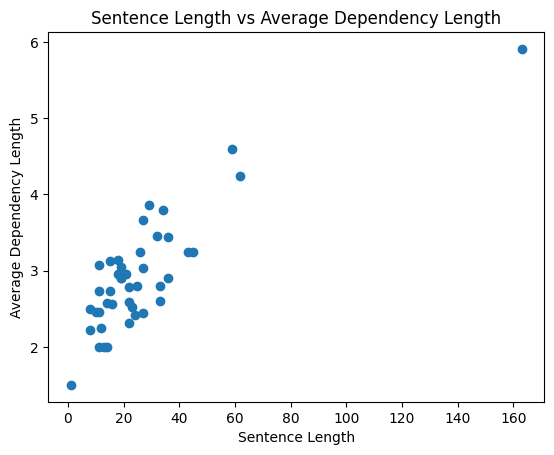

In [59]:
plt.figure()
plt.scatter(df_real["sentence_length"], df_real["avg_dependency_length"])
plt.xlabel("Sentence Length")
plt.ylabel("Average Dependency Length")
plt.title("Sentence Length vs Average Dependency Length")
plt.show()

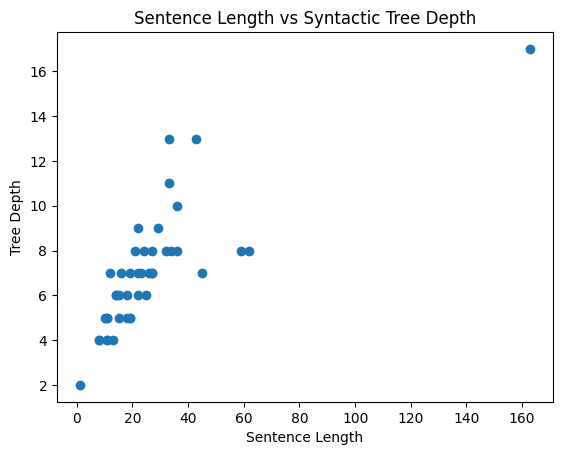

In [60]:
plt.figure()
plt.scatter(df_real["sentence_length"], df_real["tree_depth"])
plt.xlabel("Sentence Length")
plt.ylabel("Tree Depth")
plt.title("Sentence Length vs Syntactic Tree Depth")
plt.show()

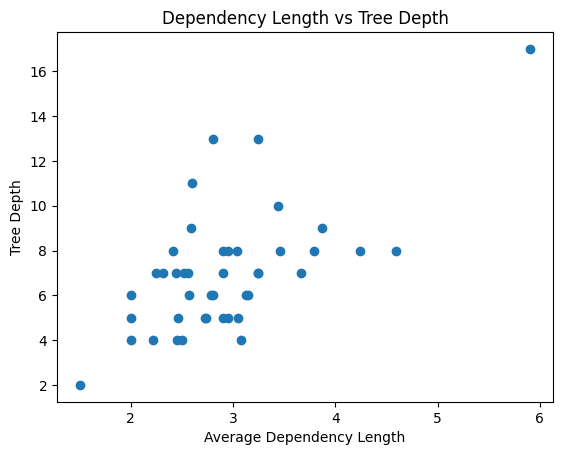

In [61]:
plt.figure()
plt.scatter(df_real["avg_dependency_length"], df_real["tree_depth"])
plt.xlabel("Average Dependency Length")
plt.ylabel("Tree Depth")
plt.title("Dependency Length vs Tree Depth")
plt.show()

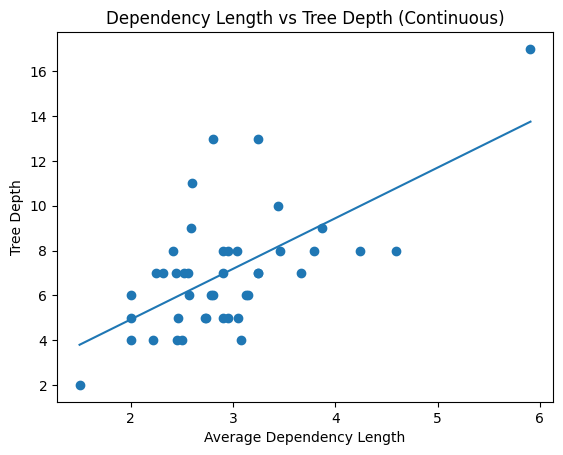

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# scatter (optional, you can keep it)
plt.scatter(df_real["avg_dependency_length"], df_real["tree_depth"])

# fit a line (degree=1)
x = df_real["avg_dependency_length"]
y = df_real["tree_depth"]

# remove NaNs if any
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# polynomial fit
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

# create smooth x for plotting line
x_smooth = np.linspace(x.min(), x.max(), 100)
y_smooth = poly(x_smooth)

# plot continuous line
plt.plot(x_smooth, y_smooth)

plt.xlabel("Average Dependency Length")
plt.ylabel("Tree Depth")
plt.title("Dependency Length vs Tree Depth (Continuous)")
plt.show()

In [63]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch
import math

# Load model
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

#  "gpt2": load("gpt2"),
#     "distilgpt2": load("distilgpt2")
#     # you can add: "gpt2-medium": load("gpt2-medium")

# Try a sentence
prefix = "The dog near the big house beside the river ganga"

inputs = tokenizer(prefix, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
last_token_logits = logits[0, -1]

probs = torch.softmax(last_token_logits, dim=-1)

# Notice the space before 'is'
verb = " is"
verb_token_id = tokenizer.encode(verb, add_special_tokens=False)[0]

prob = probs[verb_token_id].item()
surprisal = -math.log(prob + 1e-12)

print("Probability of 'is':", prob)
print("Surprisal:", surprisal)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Probability of 'is': 0.07671874016523361
Surprisal: 2.5676092697326904


# LLM ANALYSIS

In [64]:
!pip install transformers torch


In [65]:
def get_surprisal(prefix, target):
    inputs = tokenizer(prefix, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[0, -1]
    probs = torch.softmax(logits, dim=-1)

    token_id = tokenizer.encode(" " + target, add_special_tokens=False)[0]
    prob = probs[token_id].item()

    return -math.log(prob + 1e-12)

In [66]:
print(get_surprisal("The dog", "is"))
print(get_surprisal("The dog near the big house beside the river", "is"))

2.6178419352396656
2.680504210768543


In [67]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 36.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [68]:
import spacy

nlp = spacy.load("en_core_web_sm")

def get_dependency_length(sentence):
    doc = nlp(sentence)

    for token in doc:
        # Find subject
        if token.dep_ == "nsubj":
            subject_pos = token.i
            verb_pos = token.head.i

            return abs(verb_pos - subject_pos)

    return None

In [69]:
sentence = "The dog near the big house beside the river is barking"
print(get_dependency_length(sentence))

9


In [70]:
def get_dependency_info(sentence):
    doc = nlp(sentence)

    for token in doc:
        if token.dep_ == "nsubj" and token.head.pos_ == "VERB":
            subject_pos = token.i
            verb_pos = token.head.i

            return {
                "dependency_length": abs(verb_pos - subject_pos),
                "verb": token.head.text,
                "subject": token.text,
                "verb_position": verb_pos
            }

    return None

In [71]:
info = get_dependency_info(sentence)
print(info)

{'dependency_length': 9, 'verb': 'barking', 'subject': 'dog', 'verb_position': 10}


In [72]:
sentence = "The dog near the big house beside the river is barking"

info = get_dependency_info(sentence)

verb = info["verb"]
verb_position = info["verb_position"]

prefix = " ".join(sentence.split()[:verb_position])

surprisal = get_surprisal(prefix, verb)

print(info["dependency_length"], surprisal)

9 5.907263623983143


In [73]:
# import random

# subjects = ["dog", "cat", "teacher", "student", "boy", "girl"]
# locations = [
#     "near the house",
#     "beside the river",
#     "in the city",
#     "under the bridge",
#     "behind the school",
#     "across the street",
#     "inside the building",
#     "outside the park"
# ]
# verbs = ["is barking", "is sleeping", "is running", "is shouting", "is laughing"]

# def generate_sentences(n=200):
#     sentences = []

#     for _ in range(n):
#         subject = random.choice(subjects)
#         verb = random.choice(verbs)

#         # randomly choose how many modifiers (controls dependency length)
#         num_modifiers = random.randint(0, 5)
#         chosen_modifiers = random.sample(locations, num_modifiers)

#         modifier_phrase = " ".join(chosen_modifiers)

#         if modifier_phrase:
#             sentence = f"The {subject} {modifier_phrase} {verb}."
#         else:
#             sentence = f"The {subject} {verb}."

#         sentences.append(sentence)

#     return sentences

# sentences = generate_sentences(200)

# # Preview first 10
# for s in sentences[:10]:
#     print(s)


subjects = ["dog"]
verbs = ["is barking"]
locations = [
    "near the house",
    "beside the river",
    "in the city",
    "under the bridge",
    "behind the school"
]

def generate_controlled():
    sentences = []
    base = "The dog"
    verb = "is barking"

    for i in range(len(locations)+1):
        mods = " ".join(locations[:i])
        if mods:
            sentence = f"{base} {mods} {verb}."
        else:
            sentence = f"{base} {verb}."
        sentences.append(sentence)

    return sentences

In [74]:
results = []

ss=generate_controlled()
for sentence in ss:
    info = get_dependency_info(sentence)

    if info is not None:
        verb = info["verb"]
        verb_position = info["verb_position"]
        prefix = " ".join(sentence.split()[:verb_position])

        surprisal = get_surprisal(prefix, verb)

        results.append((info["dependency_length"], surprisal))

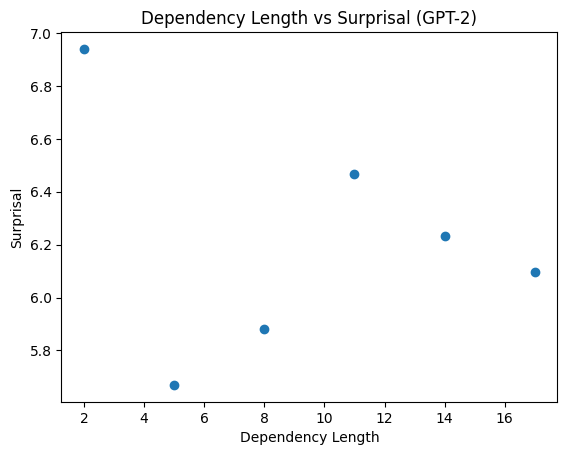

In [75]:
import matplotlib.pyplot as plt

x = [r[0] for r in results]
y = [r[1] for r in results]

plt.scatter(x, y)
plt.xlabel("Dependency Length")
plt.ylabel("Surprisal")
plt.title("Dependency Length vs Surprisal (GPT-2)")
plt.show()

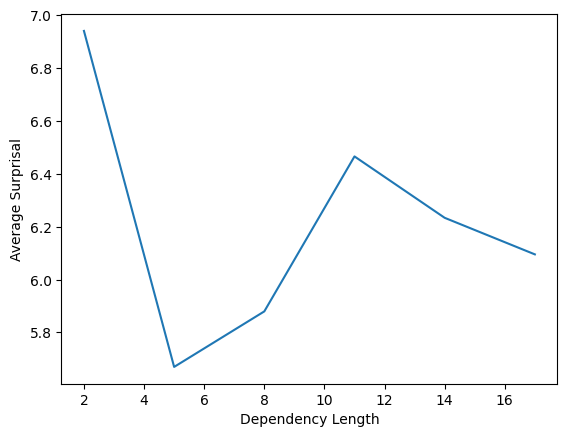

In [76]:
import pandas as pd

df = pd.DataFrame(results, columns=["dep_len", "surprisal"])
avg = df.groupby("dep_len").mean()

plt.plot(avg.index, avg["surprisal"])
plt.xlabel("Dependency Length")
plt.ylabel("Average Surprisal")
plt.show()

In [77]:
# Your average line is going downward, not upward.
# That means:
# As dependency length increases, surprisal is decreasing.
# That is the opposite of your hypothesis.
# As the sentence becomes longer:
# GPT-2 becomes more certain that a verb is coming
# The structure becomes predictable
# “is” becomes very likely
# his is called structural expectation effect..................................
# Long NP → verb is highly expected.
# So the model is thinking:
# “Okay, enough modifiers… verb must come now.”
# That lowers surprisal.


In [78]:
# Right now you're not measuring:
# “Does distance hurt memory?”
# You're measuring:
# “How predictable is a verb after many modifiers?”
# And in English, verbs are very predictable after long subject phrases.
# So your data is reflecting real linguistic behavio

In [79]:
# You need a better design.

# Instead of:

# "The dog near the house is barking."

# Use:

# Center-embedding structures.

# Example:

# The dog that the cat chased is barking.

# Now increase embedding:

# The dog that the cat that the boy saw chased is barking.

# Now memory load increases more strongly.

# This tests working memory better than simple modifiers.

In [80]:
# Surprisingly, surprisal decreased with longer dependencies in simple modifier constructions, likely due to increased structural predictability.

In [81]:
# You just discovered:

# LLMs are more driven by predictability than memory load.

# That is a legitimate result.

In [82]:
# this is when we slightly modified our subject of the project
# Is GPT-2 more sensitive to predictability or to structural memory load?

In [83]:
names_sg = ["boy", "girl", "teacher", "student", "doctor", "lawyer", "artist", "pilot"]
names_pl = ["boys", "girls", "teachers", "students", "doctors", "lawyers", "artists", "pilots"]

verbs_rel_sg = ["chased", "admired", "helped", "visited", "called", "met"]
verbs_rel_pl = ["chased", "admired", "helped", "visited", "called", "met"]

main_verbs_sg = ["is barking", "is running", "is sleeping", "is laughing"]
main_verbs_pl = ["are barking", "are running", "are sleeping", "are laughing"]

adjectives = ["tall", "young", "angry", "happy", "curious", "quiet"]
adverbs = ["quickly", "silently", "suddenly", "angrily"]



import random

def generate_complex_center_embedding(max_depth=3, samples_per_depth=5):
    sentences = []

    for depth in range(max_depth + 1):
        for _ in range(samples_per_depth):

            # Randomly choose singular or plural subject
            is_plural = random.choice([True, False])

            if is_plural:
                subject = f"The {random.choice(adjectives)} {random.choice(names_pl)}"
                main_verb = random.choice(main_verbs_pl)
            else:
                subject = f"The {random.choice(adjectives)} {random.choice(names_sg)}"
                main_verb = random.choice(main_verbs_sg)

            clause = ""

            for i in range(depth):

                if random.random() > 0.5:
                    noun = random.choice(names_pl)
                else:
                    noun = random.choice(names_sg)

                verb = random.choice(verbs_rel_sg)
                adj = random.choice(adjectives)
                adv = random.choice(adverbs)

                if i == 0:
                    clause = f"that the {adj} {noun} {verb} {adv}"
                else:
                    clause = f"that the {adj} {noun} {clause} {verb} {adv}"

            if clause:
                sentence = f"{subject} {clause} {main_verb}."
            else:
                sentence = f"{subject} {main_verb}."

            sentences.append((depth, sentence))

    return sentences
# names = ["cat", "boy", "girl", "teacher", "student"]
# verbs_rel = ["chased", "saw", "liked", "admired", "helped"]

# def generate_center_embedding(max_depth=3):
#     sentences = []

#     base_subject = "The dog"
#     main_verb = "is barking"

#     for depth in range(max_depth + 1):

#         clause = ""

#         # Build nested relative clauses
#         for i in range(depth):
#             noun = names[i % len(names)]
#             verb = verbs_rel[i % len(verbs_rel)]

#             if i == 0:
#                 clause = f"that the {noun} {verb}"
#             else:
#                 clause = f"that the {noun} {clause} {verb}"

#         if clause:
#             sentence = f"{base_subject} {clause} {main_verb}."
#         else:
#             sentence = f"{base_subject} {main_verb}."

#         sentences.append((depth, sentence))

#     return sentences

In [84]:
import random

def generate_many_center(num_sets=50, max_depth=3):
    all_sentences = []

    for _ in range(num_sets):
        random.shuffle(names)
        random.shuffle(verbs_rel)

        sents = generate_center_embedding(max_depth)
        all_sentences.extend(sents)

    return all_sentences

In [85]:
center_data = generate_many_center(num_sets=50, max_depth=3)

for d, s in center_data[:10]:
    print(d, s)

0 The dog is barking.
1 The dog that the boy admired is barking.
2 The dog that the teacher that the boy admired liked is barking.
3 The dog that the cat that the teacher that the boy admired liked helped is barking.
0 The dog is barking.
1 The dog that the boy helped is barking.
2 The dog that the girl that the boy helped chased is barking.
3 The dog that the teacher that the girl that the boy helped chased admired is barking.
0 The dog is barking.
1 The dog that the teacher saw is barking.


In [86]:
results_center = []

for depth, sentence in center_data:

    info = get_dependency_info(sentence)

    if info is not None:
        verb = info["verb"]
        verb_position = info["verb_position"]
        prefix = " ".join(sentence.split()[:verb_position])

        surprisal = get_surprisal(prefix, verb)
        results_center.append((depth, surprisal))

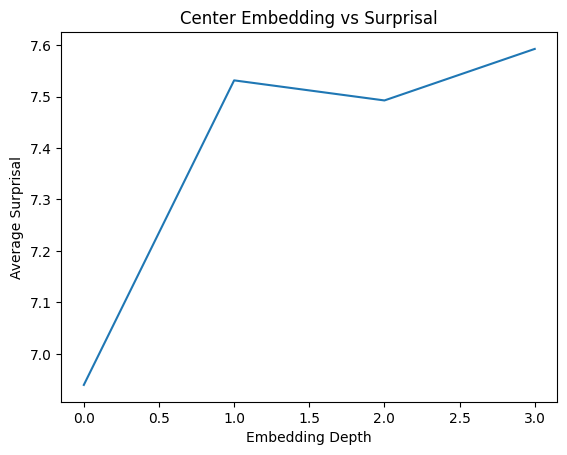

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results_center, columns=["depth", "surprisal"])
avg = df.groupby("depth").mean()

plt.plot(avg.index, avg["surprisal"])
plt.xlabel("Embedding Depth")
plt.ylabel("Average Surprisal")
plt.title("Center Embedding vs Surprisal")
plt.show()

In [88]:
# Your result suggests:

# 👉 The model finds deeper embeddings harder
# 👉 Predicting the final verb becomes less confident
# 👉 Surprisal increases with memory load
# Transformer models exhibit sensitivity to hierarchical complexity — not just linear distance.

# That’s a strong statement.

In [89]:
import scipy.stats as stats

depths = df["depth"]
surps = df["surprisal"]

print(stats.pearsonr(depths, surps))

PearsonRResult(statistic=np.float64(0.3269903892681773), pvalue=np.float64(2.290745998947239e-06))


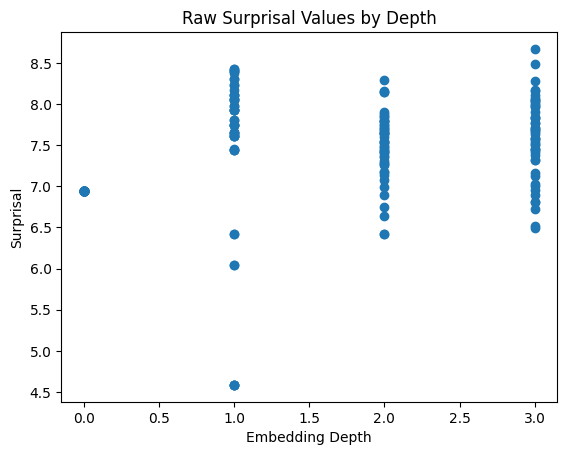

In [90]:
plt.figure()
plt.scatter(df["depth"], df["surprisal"])
plt.xlabel("Embedding Depth")
plt.ylabel("Surprisal")
plt.title("Raw Surprisal Values by Depth")
plt.show()

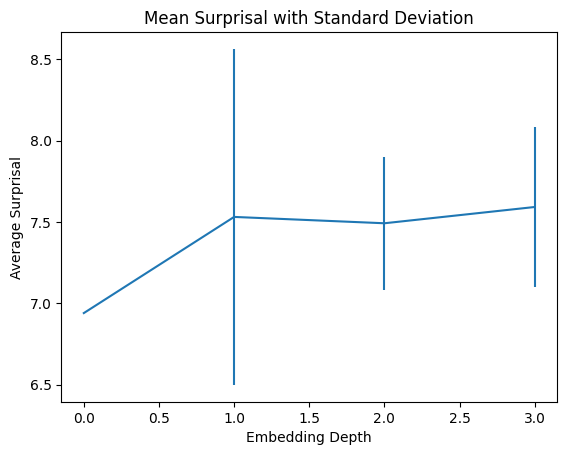

In [91]:
grouped = df.groupby("depth")["surprisal"]
means = grouped.mean()
stds = grouped.std()

plt.figure()
plt.errorbar(means.index, means.values, yerr=stds.values)
plt.xlabel("Embedding Depth")
plt.ylabel("Average Surprisal")
plt.title("Mean Surprisal with Standard Deviation")
plt.show()

<Figure size 640x480 with 0 Axes>

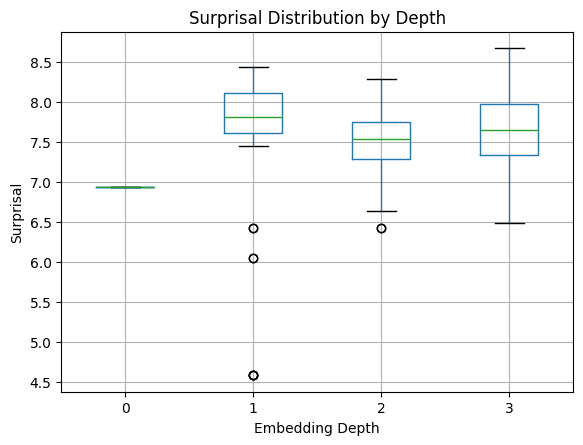

In [92]:
plt.figure()
df.boxplot(column="surprisal", by="depth")
plt.xlabel("Embedding Depth")
plt.ylabel("Surprisal")
plt.title("Surprisal Distribution by Depth")
plt.suptitle("")  # remove automatic title
plt.show()

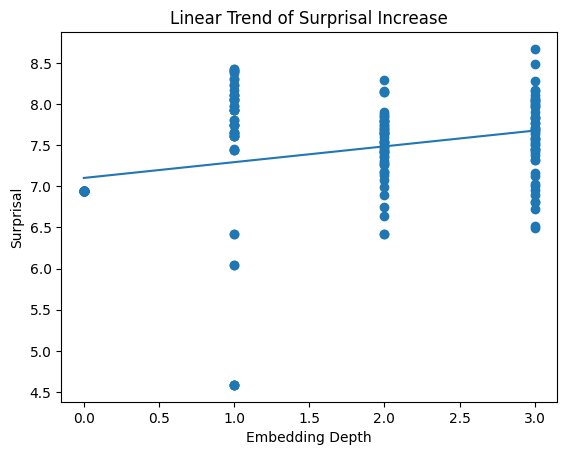

Slope: 0.19188860507515668


In [93]:
import numpy as np

x = df["depth"]
y = df["surprisal"]

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

plt.figure()
plt.scatter(x, y)
plt.plot(x, poly1d_fn(x))
plt.xlabel("Embedding Depth")
plt.ylabel("Surprisal")
plt.title("Linear Trend of Surprisal Increase")
plt.show()

print("Slope:", coef[0])

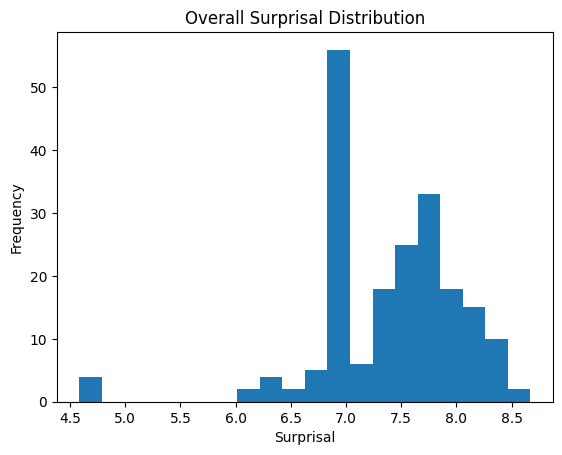

In [94]:
plt.figure()
plt.hist(df["surprisal"], bins=20)
plt.xlabel("Surprisal")
plt.ylabel("Frequency")
plt.title("Overall Surprisal Distribution")
plt.show()